In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
DATA_DIR = Path("../data/raw")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"

# train 폴더 안에 있는 우물 ID 목록 만들기
well_ids = sorted(set(
    f.stem.split("__")[0]
    for f in TRAIN_DIR.glob("*__horizontal_well.csv")
))

print(f"총 우물 수: {len(well_ids)}")
print(f"첫 5개 우물 ID: {well_ids[:5]}")

총 우물 수: 773
첫 5개 우물 ID: ['000d7d20', '00bbac68', '00e12e8b', '015fe0d2', '01869cd4']


In [3]:
wid = well_ids[0]  # 첫 번째 우물 ID

hw = pd.read_csv(TRAIN_DIR / f"{wid}__horizontal_well.csv")
tw = pd.read_csv(TRAIN_DIR / f"{wid}__typewell.csv")

print("=== 수평 우물 (horizontal_well) ===")
print(hw.shape)
print(hw.head())

print("\n=== 타입웰 (typewell) ===")
print(tw.shape)
print(tw.head())

=== 수평 우물 (horizontal_well) ===
(5278, 13)
        MD           X           Y        Z     ANCC    ASTNU    ASTNL  \
0  11467.0  2983525.16  1069022.09 -9258.57 -9395.81 -9569.86 -9597.64   
1  11468.0  2983525.18  1069022.30 -9259.55 -9395.75 -9569.80 -9597.58   
2  11469.0  2983525.20  1069022.52 -9260.52 -9395.69 -9569.74 -9597.52   
3  11470.0  2983525.22  1069022.73 -9261.50 -9395.64 -9569.69 -9597.47   
4  11471.0  2983525.25  1069022.95 -9262.47 -9395.58 -9569.63 -9597.41   

     EGFDU    EGFDL     BUDA       TVT          GR  TVT_input  
0 -9670.99 -9705.96 -9846.35  11236.02  115.692586   11236.02  
1 -9670.93 -9705.90 -9846.29  11237.05  115.584293   11237.05  
2 -9670.87 -9705.84 -9846.23  11238.09  135.446960   11238.09  
3 -9670.82 -9705.79 -9846.18  11239.12  140.401346   11239.12  
4 -9670.76 -9705.73 -9846.12  11240.15  111.270638   11240.15  

=== 타입웰 (typewell) ===
(1296, 3)
        TVT      GR Geology
0  11223.95  126.11     NaN
1  11224.45  128.22     NaN
2  11224.9

In [4]:
print("=== 수평 우물 결측값 ===")
print(hw.isnull().sum())

print("\n=== 수평 우물 기본 통계 ===")
print(hw.describe())

=== 수평 우물 결측값 ===
MD              0
X               0
Y               0
Z               0
ANCC            0
ASTNU           0
ASTNL           0
EGFDU           0
EGFDL           0
BUDA            0
TVT             0
GR           2258
TVT_input    3836
dtype: int64

=== 수평 우물 기본 통계 ===
                 MD             X             Y            Z         ANCC  \
count   5278.000000  5.278000e+03  5.278000e+03  5278.000000  5278.000000   
mean   14105.500000  2.983514e+06  1.071418e+06 -9673.194324 -9330.621821   
std     1523.771691  2.997379e+01  1.503381e+03    80.961903    35.272977   
min    11467.000000  2.983468e+06  1.069022e+06 -9755.610000 -9395.810000   
25%    12786.250000  2.983487e+06  1.070090e+06 -9721.762500 -9362.307500   
50%    14105.500000  2.983514e+06  1.071407e+06 -9689.230000 -9335.975000   
75%    15424.750000  2.983535e+06  1.072723e+06 -9650.035000 -9296.665000   
max    16744.000000  2.983578e+06  1.074041e+06 -9258.570000 -9271.000000   

             ASTNU  

C:\Users\sodpw\AppData\Local\Temp\ipykernel_31492\1426103383.py:17: UserWarning: Glyph 44618 (\N{HANGUL SYLLABLE GIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sodpw\AppData\Local\Temp\ipykernel_31492\1426103383.py:17: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sodpw\AppData\Local\Temp\ipykernel_31492\1426103383.py:17: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sodpw\AppData\Local\Temp\ipykernel_31492\1426103383.py:17: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sodpw\AppData\Local\Temp\ipykernel_31492\1426103383.py:17: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sodpw\AppData\Local\Temp\ipykernel_31492\1426103383.py:17: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font

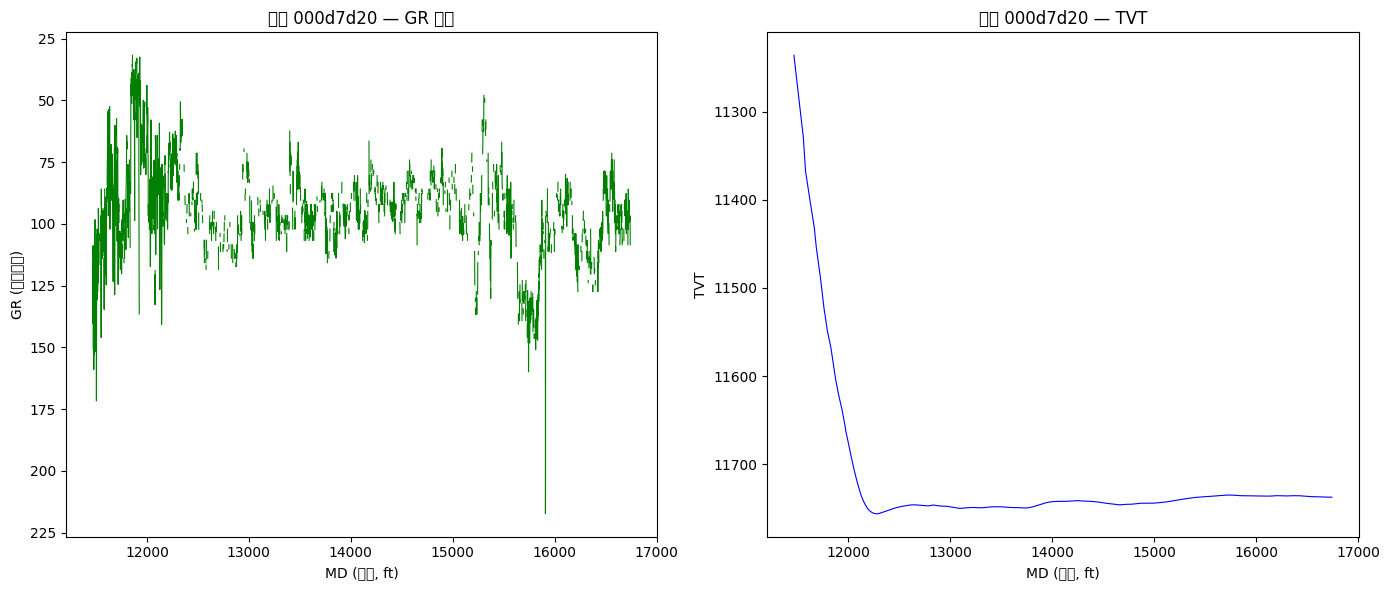

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: GR 값 변화 (깊이에 따라)
axes[0].plot(hw["MD"], hw["GR"], color="green", linewidth=0.8)
axes[0].set_xlabel("MD (깊이, ft)")
axes[0].set_ylabel("GR (감마레이)")
axes[0].set_title(f"우물 {wid} — GR 로그")
axes[0].invert_yaxis()   # 깊이는 아래로 갈수록 커지니까 y축 뒤집기

# 오른쪽: TVT 값 변화
axes[1].plot(hw["MD"], hw["TVT"], color="blue", linewidth=0.8)
axes[1].set_xlabel("MD (깊이, ft)")
axes[1].set_ylabel("TVT")
axes[1].set_title(f"우물 {wid} — TVT")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [6]:
# 전체 우물의 TVT_input 결측 비율과 GR 결측 비율 계산
stats = []

for wid in well_ids:
    hw = pd.read_csv(TRAIN_DIR / f"{wid}__horizontal_well.csv")
    stats.append({
        "well_id": wid,
        "n_rows": len(hw),
        "gr_missing_pct": hw["GR"].isnull().mean() * 100,
        "tvt_input_missing_pct": hw["TVT_input"].isnull().mean() * 100,
    })

stats_df = pd.DataFrame(stats)
print(stats_df.describe())

             n_rows  gr_missing_pct  tvt_input_missing_pct
count    773.000000      773.000000             773.000000
mean    6587.652005       29.385406              73.316082
std     1311.463547       19.085710               6.377561
min     2058.000000        0.652722              19.776482
25%     5706.000000       12.119830              70.034423
50%     6576.000000       27.703783              73.999107
75%     7388.000000       46.395180              77.546187
max    12141.000000       80.098901              87.516484


C:\Users\sodpw\AppData\Local\Temp\ipykernel_31492\3385141871.py:26: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sodpw\AppData\Local\Temp\ipykernel_31492\3385141871.py:26: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sodpw\AppData\Local\Temp\ipykernel_31492\3385141871.py:26: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sodpw\AppData\Local\Temp\ipykernel_31492\3385141871.py:26: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\sodpw\Projects\ROGII\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sodpw\Projects\ROGII\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWa

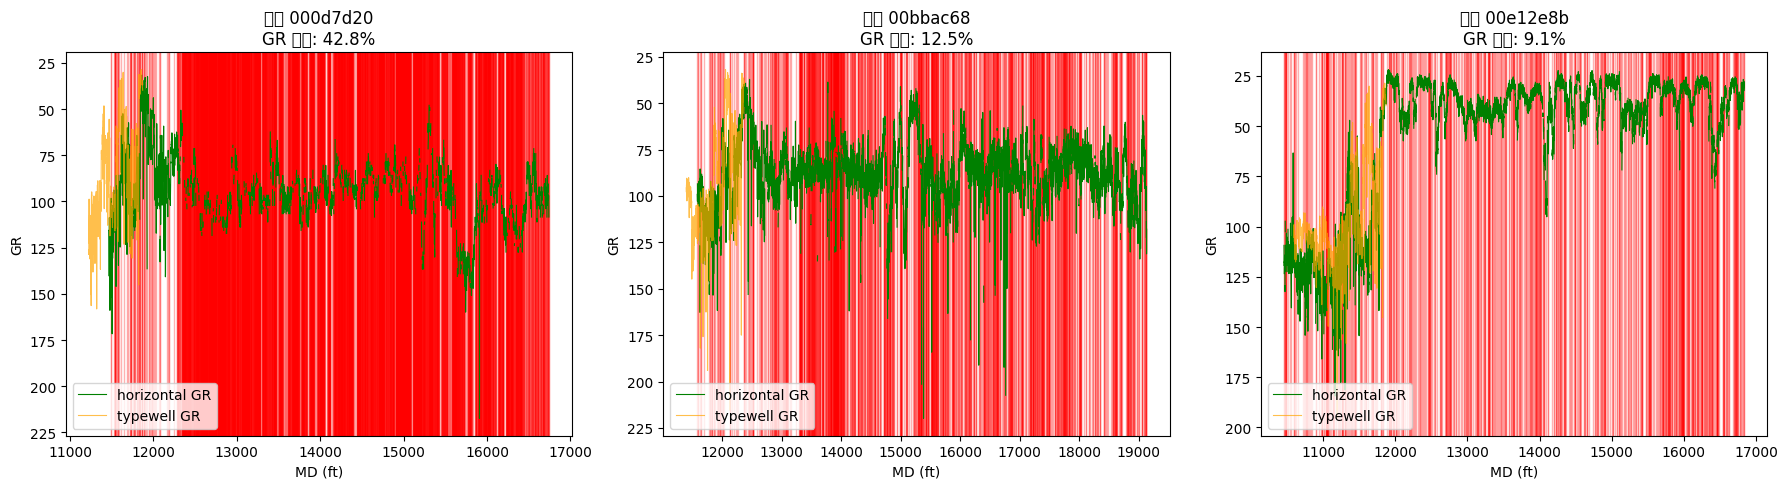

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, wid in enumerate(well_ids[:3]):   # 우물 3개만 샘플로 봐요
    hw = pd.read_csv(TRAIN_DIR / f"{wid}__horizontal_well.csv")
    tw = pd.read_csv(TRAIN_DIR / f"{wid}__typewell.csv")
    
    ax = axes[i]
    
    # GR 있는 구간 = 파란색, 없는 구간 = 배경 빨간색으로 표시
    ax.plot(hw["MD"], hw["GR"], color="green", linewidth=0.8, label="horizontal GR")
    ax.plot(tw["TVT"], tw["GR"], color="orange", linewidth=0.8, label="typewell GR", alpha=0.7)
    
    # GR 결측 구간 빨간 배경으로 표시
    missing = hw["GR"].isnull()
    for j in range(len(hw)):
        if missing.iloc[j]:
            ax.axvspan(hw["MD"].iloc[j], hw["MD"].iloc[j] + 1,
                       color="red", alpha=0.3)
    
    ax.set_title(f"우물 {wid}\nGR 결측: {missing.mean()*100:.1f}%")
    ax.set_xlabel("MD (ft)")
    ax.set_ylabel("GR")
    ax.legend()
    ax.invert_yaxis()

plt.tight_layout()
plt.show()